# Description Ablation — 27B vs 8B Model Comparison

**Experiment:** Two models, each run with and without domain descriptions · random picking · k=1 · 8 seeds per dataset

| Model | Exp ID | Condition A (`use_label_desc=0`) | Condition B (`use_label_desc=1`) |
|---|---|---|---|
| **Qwen3.6-27B-image-ts** | `random_k1_desc_comparison_new` | No description | With description |
| **Qwen3-VL-8B-Instruct** | `Qwen/Qwen3-VL-8B-Instruct` | No description | With description |

Evaluated on the **30 UCR datasets** that have a `description.txt` in `ucr_descriptions/`.

In [26]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import operator, math, networkx
from pathlib import Path
from scipy.stats import wilcoxon, friedmanchisquare

if wandb.api.api_key is None:
    for folder in ["wandb_logger", "logger", ""]:
        token_path = Path(folder) / "token.txt"
        if token_path.exists():
            wandb.login(key=token_path.read_text().strip())
            break

ENTITY  = "aviramom-"
PROJECT = "multits"

EXP_27B = "random_k1_desc_comparison_new"
EXP_8B  = "random_k1_desc_comparison_qwenvl8b"

COND_27B_NO   = "27B · No Desc"
COND_27B_WITH = "27B · With Desc"
COND_8B_NO    = "8B · No Desc"
COND_8B_WITH  = "8B · With Desc"
CONDITIONS    = [COND_27B_NO, COND_27B_WITH, COND_8B_NO, COND_8B_WITH]

REF_COLS   = ["DTW (w=100)", "Default Rate"]
DELTA_COLS = ["Δ 27B (with−no)", "Δ 8B (with−no)"]
EXTRA_COLS = REF_COLS + DELTA_COLS

api = wandb.Api(timeout=60)
print(f"Connected to {ENTITY}/{PROJECT}")
print(f"  27B exp : {EXP_27B}")
print(f"  8B  exp : {EXP_8B}")

Connected to aviramom-/multits
  27B exp : random_k1_desc_comparison_new
  8B  exp : random_k1_desc_comparison_qwenvl8b


## 1 · Load Data from W&B

Runs are fetched from W&B and cached locally. Set `FORCE_REFRESH = True` when new runs finish.
Two separate caches: one per experiment.

In [27]:
from tqdm.auto import tqdm

CONFIG_KEYS = ["task_id", "method", "num_samples", "exp_id", "input_mode",
               "num_shots", "random_seed", "picking_strategy", "use_label_desc"]
METRIC_KEYS = ["final_accuracy", "final_balanced_accuracy", "final_num_of_classes",
               "total_test_size", "flawed_count", "flawed_percentage"]

CACHE_27B     = Path("cache_random_k1_desc_comparison_new.parquet")
CACHE_8B      = Path("cache_8b_desc_comparison.parquet")
FORCE_REFRESH = False   # set True when new runs finish

def get_val(cfg, summary, key):
    return summary.get(key, cfg.get(key))

def fetch_exp(exp_id, cache_path):
    if cache_path.exists() and not FORCE_REFRESH:
        df = pd.read_parquet(cache_path)
        print(f"Loaded {len(df)} rows from cache ({cache_path})")
        return df
    all_runs = list(api.runs(path=f"{ENTITY}/{PROJECT}", per_page=1000))
    rows = []
    for run in tqdm(all_runs, desc=f"Processing {exp_id}"):
        summary = {k: v for k, v in (run.summary or {}).items() if not k.startswith("_")}
        cfg     = run.config or {}
        if get_val(cfg, summary, "exp_id") != exp_id:
            continue
        row = {"run_id": run.id, "run_name": run.name, "state": run.state}
        for k in CONFIG_KEYS:
            row[k] = get_val(cfg, summary, k)
        for k in METRIC_KEYS:
            row[k] = get_val(cfg, summary, k)
        rows.append(row)
    df = pd.DataFrame(rows)
    for col in METRIC_KEYS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df.to_parquet(cache_path)
    print(f"Cached {len(df)} rows → {cache_path}")
    return df

df_27b = fetch_exp(EXP_27B, CACHE_27B)
df_8b  = fetch_exp(EXP_8B,  CACHE_8B)

def label_condition(df, no_label, with_label):
    df = df.copy()
    df["condition"] = (
        pd.to_numeric(df["use_label_desc"], errors="coerce")
        .fillna(0).astype(int)
        .map({0: no_label, 1: with_label})
    )
    return df

df_27b = label_condition(df_27b, COND_27B_NO, COND_27B_WITH)
df_8b  = label_condition(df_8b,  COND_8B_NO,  COND_8B_WITH)

df = pd.concat([df_27b, df_8b], ignore_index=True)
df["task"] = df["task_id"].str.replace("icl_ucr_", "", regex=False)

print(f"\n{'─'*50}")
print(f"Total runs loaded : {len(df)}")
for exp_id, label in [(EXP_27B, "27B"), (EXP_8B, "8B")]:
    sub = df[df["exp_id"] == exp_id]
    print(f"\n{label} ({exp_id}):")
    print(f"  Total     : {len(sub)}")
    print(f"  Finished  : {(sub['state'] == 'finished').sum()}")
    print(f"  Conditions: {sub['condition'].value_counts().to_dict()}")

Loaded 502 rows from cache (cache_random_k1_desc_comparison_new.parquet)
Loaded 480 rows from cache (cache_8b_desc_comparison.parquet)

──────────────────────────────────────────────────
Total runs loaded : 982

27B (random_k1_desc_comparison_new):
  Total     : 502
  Finished  : 480
  Conditions: {'27B · No Desc': 253, '27B · With Desc': 249}

8B (random_k1_desc_comparison_qwenvl8b):
  Total     : 480
  Finished  : 480
  Conditions: {'8B · No Desc': 240, '8B · With Desc': 240}


In [28]:
import sys, os
sys.path.insert(0, "." if os.path.exists("data_provider") else "..")
from data_provider.dataset_iclucr import UCR_DESCRIPTIONS

DESC_TASKS = set(UCR_DESCRIPTIONS.keys())
finished   = df[(df["state"] == "finished") & (df["task"].isin(DESC_TASKS))].copy()
tasks      = sorted(finished["task"].unique())

print(f"Datasets with description files : {len(DESC_TASKS)}")
print(f"Datasets present in results     : {len(tasks)}")
missing = DESC_TASKS - set(tasks)
if missing:
    print(f"Missing from results ({len(missing)}): {sorted(missing)}")

for cond_pair, label in [([COND_27B_NO, COND_27B_WITH], "27B"), ([COND_8B_NO, COND_8B_WITH], "8B")]:
    sub = finished[finished["condition"].isin(cond_pair)]
    print(f"\n{label} — {sub['task'].nunique()} tasks, {len(sub)} finished runs")

Datasets with description files : 30
Datasets present in results     : 30

27B — 30 tasks, 480 finished runs

8B — 30 tasks, 480 finished runs


## 2 · Results

Balanced accuracy (average per-class recall) — mean ± std across 8 seeds.
Columns: 27B No Desc · 27B With Desc · Δ 27B · 8B No Desc · 8B With Desc · Δ 8B · DTW · Default Rate

In [29]:
import re

# ── UCR reference data ────────────────────────────────────────────────────────
try:
    summary_raw = pd.read_csv("icl_data/DataSummary.csv")
    summary_raw.columns = summary_raw.columns.str.strip()
    def _parse_err(val):
        m = re.match(r"\s*([\d.]+)", str(val))
        return float(m.group(1)) if m else np.nan
    summary_raw["DTW_acc"]         = 1.0 - summary_raw["DTW (w=100)"].apply(_parse_err)
    summary_raw["num_classes"]     = pd.to_numeric(summary_raw["Class"], errors="coerce")
    summary_raw["default_bal_acc"] = 1.0 / summary_raw["num_classes"]
    ucr_ref = summary_raw.set_index("Name")[["DTW_acc", "default_bal_acc"]]
    HAS_REF = True
except FileNotFoundError:
    ucr_ref, HAS_REF = pd.DataFrame(), False
    print("UCR reference CSV not found — reference columns omitted.")

# ── Pivot ─────────────────────────────────────────────────────────────────────
mean_p = finished.pivot_table(index="task", columns="condition",
                               values="final_balanced_accuracy", aggfunc="mean")
std_p  = finished.pivot_table(index="task", columns="condition",
                               values="final_balanced_accuracy", aggfunc="std")

cols   = [c for c in CONDITIONS if c in mean_p.columns]
mean_p = mean_p[cols].reindex(tasks)
std_p  = std_p[cols].reindex(tasks)
mean_p.columns.name = std_p.columns.name = ""

if HAS_REF:
    mean_p["DTW (w=100)"]  = [ucr_ref.loc[t, "DTW_acc"]         if t in ucr_ref.index else np.nan for t in tasks]
    mean_p["Default Rate"] = [ucr_ref.loc[t, "default_bal_acc"] if t in ucr_ref.index else np.nan for t in tasks]

if COND_27B_NO in mean_p.columns and COND_27B_WITH in mean_p.columns:
    mean_p["Δ 27B (with−no)"] = mean_p[COND_27B_WITH] - mean_p[COND_27B_NO]
if COND_8B_NO in mean_p.columns and COND_8B_WITH in mean_p.columns:
    mean_p["Δ 8B (with−no)"]  = mean_p[COND_8B_WITH]  - mean_p[COND_8B_NO]

macro = mean_p.mean(axis=0); macro.name = "Macro Avg"
mean_p = pd.concat([mean_p, macro.to_frame().T])
mean_p.index.name = "Task"

fmt = mean_p.copy().astype(object)
for col in mean_p.columns:
    for idx in mean_p.index:
        m_val = mean_p.loc[idx, col]
        if col not in EXTRA_COLS and idx != "Macro Avg" and col in std_p.columns and idx in std_p.index:
            s_val = std_p.loc[idx, col]
            fmt.loc[idx, col] = f"{m_val:.3f} ± {s_val:.3f}" if pd.notna(m_val) else "—"
        else:
            fmt.loc[idx, col] = f"{m_val:.3f}" if pd.notna(m_val) else "—"

print("BALANCED ACCURACY  (mean ± std over seeds)")
display(
    fmt.style
    .set_caption("Balanced Accuracy — 27B vs 8B · No Desc vs With Desc")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

BALANCED ACCURACY  (mean ± std over seeds)


,27B · No Desc,27B · With Desc,8B · No Desc,8B · With Desc,DTW (w=100),Default Rate,Δ 27B (with−no),Δ 8B (with−no)
Task,,,,,,,,
AllGestureWiimoteX,0.292 ± 0.047,0.269 ± 0.050,0.217 ± 0.032,0.192 ± 0.050,0.716,0.100,-0.023,-0.025
AllGestureWiimoteY,0.323 ± 0.056,0.288 ± 0.035,0.265 ± 0.028,0.236 ± 0.029,0.729,0.100,-0.035,-0.029
AllGestureWiimoteZ,0.271 ± 0.021,0.280 ± 0.037,0.214 ± 0.015,0.260 ± 0.022,0.643,0.100,0.009,0.046
BME,0.699 ± 0.066,1.000 ± 0.000,0.774 ± 0.027,0.998 ± 0.003,0.900,0.333,0.301,0.224
Chinatown,0.765 ± 0.085,0.779 ± 0.097,0.675 ± 0.094,0.684 ± 0.063,0.956,0.500,0.014,0.009
Crop,0.243 ± 0.015,0.227 ± 0.024,0.201 ± 0.024,0.135 ± 0.027,0.665,0.042,-0.017,-0.066
DodgersLoopDay,—,—,—,—,—,—,—,—
DodgersLoopGame,—,—,—,—,—,—,—,—
DodgersLoopWeekend,—,—,—,—,—,—,—,—


### Balanced Accuracy Heatmap

Red–green for accuracy columns; diverging blue–red for the Δ columns (one per model).

In [30]:
tbl        = mean_p.drop(index="Macro Avg", errors="ignore")
model_cols = [c for c in cols if c in tbl.columns]
delta_cols = [c for c in DELTA_COLS if c in tbl.columns]

display(
    tbl[model_cols].style
    .background_gradient(cmap="RdYlGn", axis=None, vmin=0, vmax=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Balanced Accuracy — all 4 conditions")
)

if delta_cols:
    vabs = tbl[delta_cols].abs().max().max()
    display(
        tbl[delta_cols].style
        .background_gradient(cmap="RdBu", axis=None, vmin=-vabs, vmax=vabs)
        .format("{:.3f}", na_rep="—")
        .set_caption("Δ per model  (With Desc − No Desc)")
    )

if HAS_REF:
    display(tbl[REF_COLS].style.format("{:.3f}", na_rep="—").set_caption("UCR reference — Balanced Accuracy"))

,27B · No Desc,27B · With Desc,8B · No Desc,8B · With Desc
Task,,,,
AllGestureWiimoteX,0.292,0.269,0.217,0.192
AllGestureWiimoteY,0.323,0.288,0.265,0.236
AllGestureWiimoteZ,0.271,0.280,0.214,0.260
BME,0.699,1.000,0.774,0.998
Chinatown,0.765,0.779,0.675,0.684
Crop,0.243,0.227,0.201,0.135
DodgersLoopDay,—,—,—,—
DodgersLoopGame,—,—,—,—
DodgersLoopWeekend,—,—,—,—


,Δ 27B (with−no),Δ 8B (with−no)
Task,,
AllGestureWiimoteX,-0.023,-0.025
AllGestureWiimoteY,-0.035,-0.029
AllGestureWiimoteZ,0.009,0.046
BME,0.301,0.224
Chinatown,0.014,0.009
Crop,-0.017,-0.066
DodgersLoopDay,—,—
DodgersLoopGame,—,—
DodgersLoopWeekend,—,—


,DTW (w=100),Default Rate
Task,,
AllGestureWiimoteX,0.716,0.100
AllGestureWiimoteY,0.729,0.100
AllGestureWiimoteZ,0.643,0.100
BME,0.900,0.333
Chinatown,0.956,0.500
Crop,0.665,0.042
DodgersLoopDay,—,—
DodgersLoopGame,—,—
DodgersLoopWeekend,—,—


### Completed Runs per (Task, Condition) — target: 8

In [31]:
count_tbl = finished.pivot_table(
    index="task", columns="condition",
    values="final_balanced_accuracy", aggfunc="count"
).fillna(0).astype(int)
count_tbl = count_tbl[[c for c in CONDITIONS if c in count_tbl.columns]]
count_tbl.index.name = "Task"; count_tbl.columns.name = ""

display(
    count_tbl.style
    .background_gradient(cmap="YlGn", axis=None, vmin=0, vmax=8)
    .set_caption("Completed runs per (task, condition) — target: 8")
)

,27B · No Desc,27B · With Desc,8B · No Desc,8B · With Desc
Task,,,,
AllGestureWiimoteX,8,8,8,8
AllGestureWiimoteY,8,8,8,8
AllGestureWiimoteZ,8,8,8,8
BME,8,8,8,8
Chinatown,8,8,8,8
Crop,8,8,8,8
DodgersLoopDay,0,0,0,0
DodgersLoopGame,0,0,0,0
DodgersLoopWeekend,0,0,0,0


### Per-Task Winner

Best condition (across all 4) highlighted in green per row.

In [32]:
def highlight_winner_row(row):
    styles  = [""] * len(row)
    cond_c  = [c for c in row.index if c not in EXTRA_COLS]
    if not cond_c or row[cond_c].isna().all():
        return styles
    best_col = row[cond_c].idxmax()
    for i, col in enumerate(row.index):
        if col == best_col:
            styles[i] = "background-color: #4CAF50; color: white; font-weight: bold"
    return styles

tbl = mean_p.drop(index="Macro Avg", errors="ignore")
display(
    tbl.style
    .apply(highlight_winner_row, axis=1)
    .format("{:.3f}", na_rep="—")
    .set_caption("Winner per task (green) — across all 4 conditions")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)

,27B · No Desc,27B · With Desc,8B · No Desc,8B · With Desc,DTW (w=100),Default Rate,Δ 27B (with−no),Δ 8B (with−no)
Task,,,,,,,,
AllGestureWiimoteX,0.292,0.269,0.217,0.192,0.716,0.100,-0.023,-0.025
AllGestureWiimoteY,0.323,0.288,0.265,0.236,0.729,0.100,-0.035,-0.029
AllGestureWiimoteZ,0.271,0.280,0.214,0.260,0.643,0.100,0.009,0.046
BME,0.699,1.000,0.774,0.998,0.900,0.333,0.301,0.224
Chinatown,0.765,0.779,0.675,0.684,0.956,0.500,0.014,0.009
Crop,0.243,0.227,0.201,0.135,0.665,0.042,-0.017,-0.066
DodgersLoopDay,—,—,—,—,—,—,—,—
DodgersLoopGame,—,—,—,—,—,—,—,—
DodgersLoopWeekend,—,—,—,—,—,—,—,—


### Win Count Summary

How many datasets does each of the 4 conditions win?

In [33]:
tbl     = mean_p.drop(index="Macro Avg", errors="ignore")
mcols   = [c for c in tbl.columns if c not in EXTRA_COLS]
winners = tbl[mcols].idxmax(axis=1)
wins    = winners.value_counts().reindex(mcols, fill_value=0)
total   = len(tbl)
summary = pd.DataFrame({"Datasets Won": wins, "Win %": (wins / total * 100).round(1)})
summary = summary.sort_values("Datasets Won", ascending=False)

print(f"Win counts — Balanced Accuracy  (out of {total} datasets)")
display(
    summary.style
    .background_gradient(cmap="YlGn", subset=["Datasets Won"], axis=0)
    .format({"Datasets Won": "{:d}", "Win %": "{:.1f}%"})
    .set_caption("# datasets each condition wins")
)

Win counts — Balanced Accuracy  (out of 30 datasets)


/tmp/ipykernel_3923672/829187008.py:3: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  winners = tbl[mcols].idxmax(axis=1)


,Datasets Won,Win %
27B · With Desc,13,43.3%
27B · No Desc,12,40.0%
8B · No Desc,1,3.3%
8B · With Desc,1,3.3%


## 3 · Per-Dataset Delta

Δ = **With Description** − **No Description**, plotted separately for each model.
Green = description helps, red = description hurts.

Qwen3.6-27B:
  Mean Δ            : +0.0042
  Datasets improved : 13 / 27
  Datasets hurt     : 14 / 27
  Datasets tied     : 0 / 27

Qwen3-VL-8B:
  Mean Δ            : -0.0155
  Datasets improved : 8 / 27
  Datasets hurt     : 19 / 27
  Datasets tied     : 0 / 27



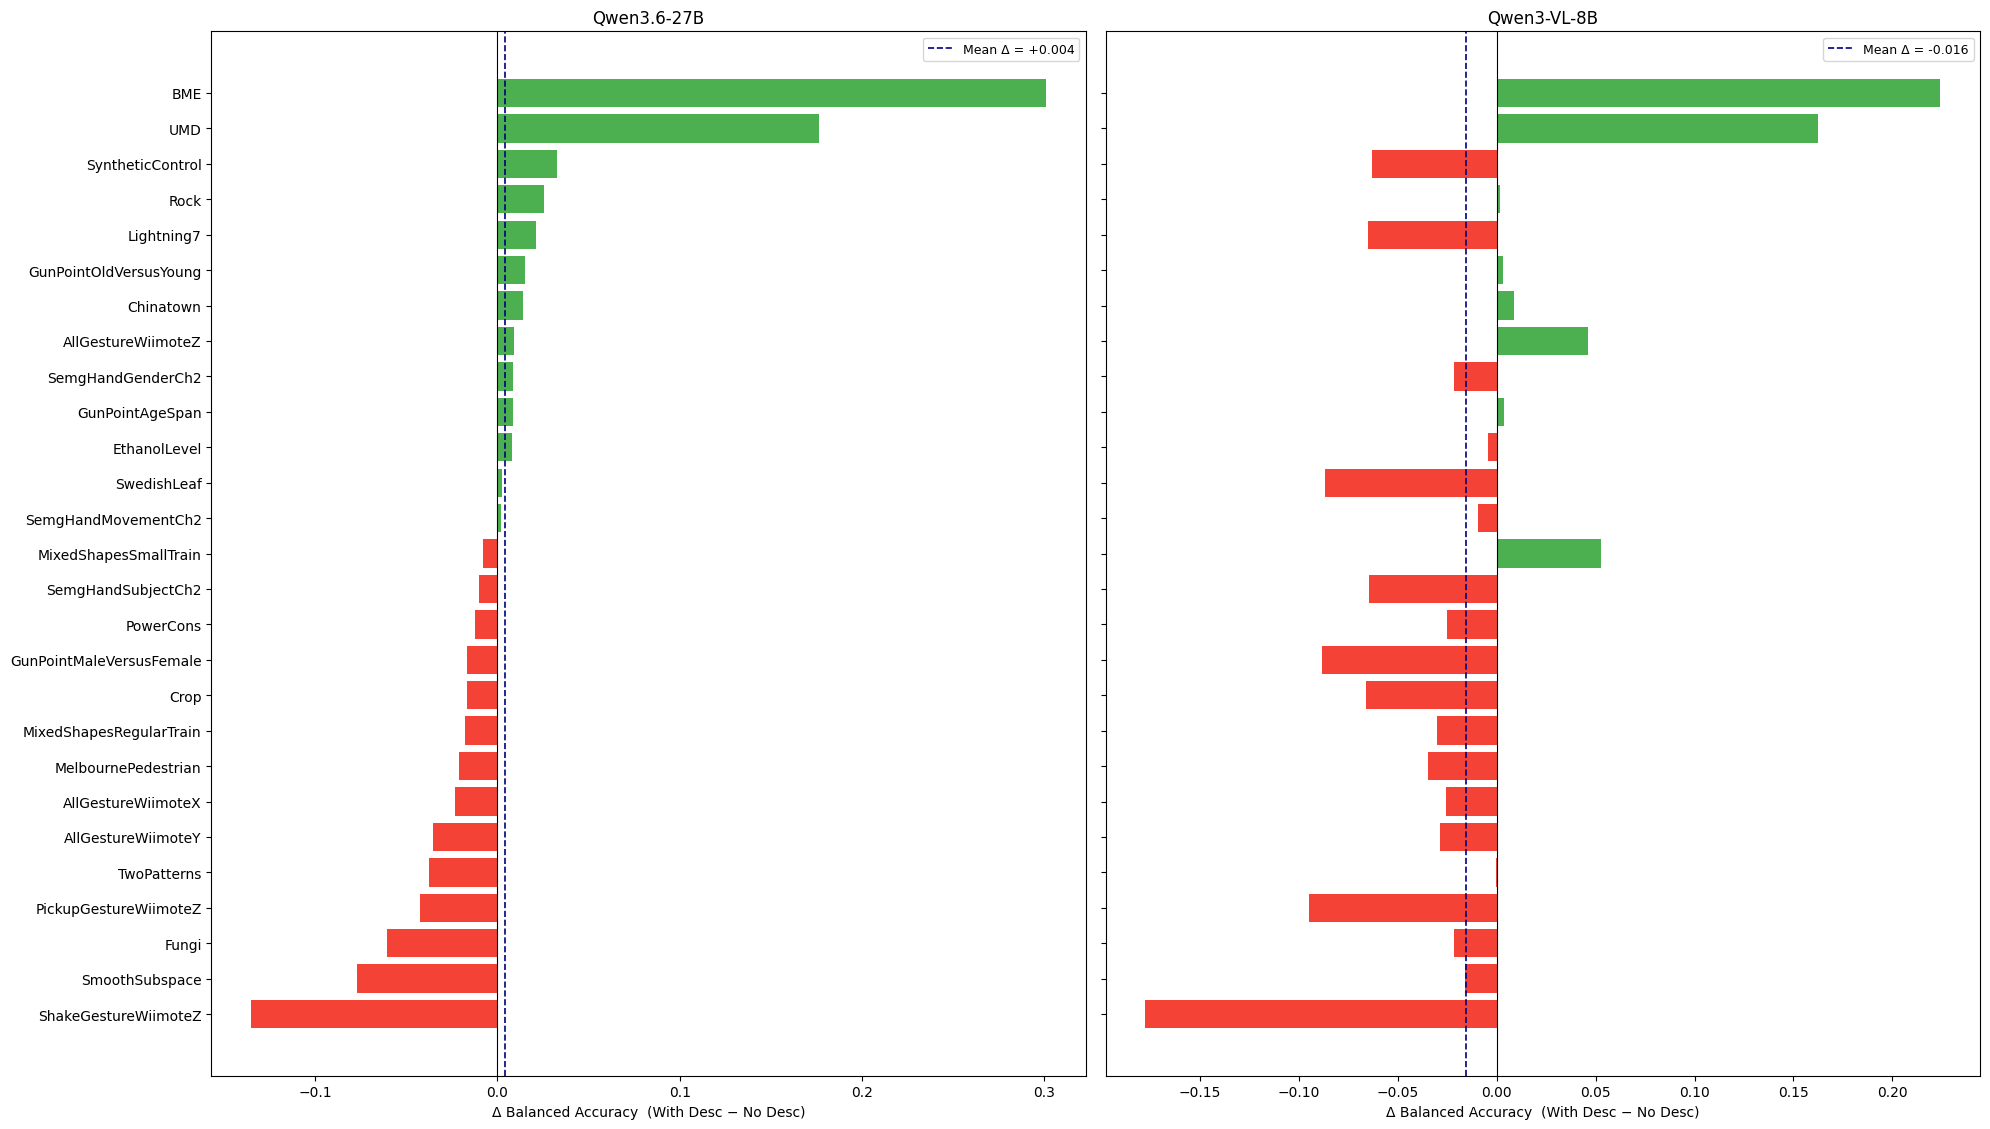

In [34]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

model_pairs = [
    (COND_27B_NO, COND_27B_WITH, "Qwen3.6-27B"),
    (COND_8B_NO,  COND_8B_WITH,  "Qwen3-VL-8B"),
]
available = [(a, b, lbl) for a, b, lbl in model_pairs if a in tbl.columns and b in tbl.columns]

fig, axes = plt.subplots(1, len(available),
                         figsize=(10 * len(available), max(4, len(tasks) * 0.38)),
                         sharey=True)
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label) in zip(axes, available):
    delta  = (tbl[cond_b] - tbl[cond_a]).dropna().sort_values(ascending=False)
    colors = ["#4CAF50" if v >= 0 else "#F44336" for v in delta]
    ax.barh(delta.index[::-1], delta.values[::-1], color=colors[::-1])
    ax.axvline(0, color="black", linewidth=0.8)
    mean_d = delta.mean()
    ax.axvline(mean_d, color="navy", linewidth=1.2, linestyle="--", label=f"Mean Δ = {mean_d:+.3f}")
    ax.set_xlabel("Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.set_title(f"{model_label}")
    ax.legend(fontsize=9)

    print(f"{model_label}:")
    print(f"  Mean Δ            : {mean_d:+.4f}")
    print(f"  Datasets improved : {(delta > 0).sum()} / {len(delta)}")
    print(f"  Datasets hurt     : {(delta < 0).sum()} / {len(delta)}")
    print(f"  Datasets tied     : {(delta == 0).sum()} / {len(delta)}")
    print()

plt.tight_layout(); plt.show()

### Scatter: No Description vs With Description

One scatter per model. Points above the diagonal → description helps on that dataset.

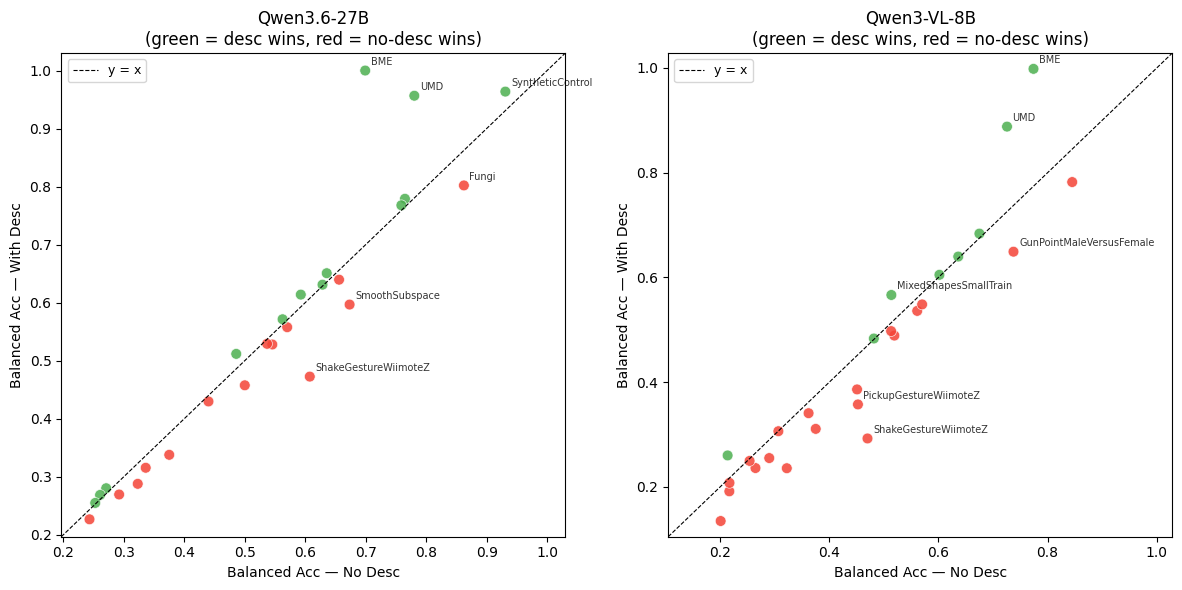

In [35]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

model_pairs = [
    (COND_27B_NO, COND_27B_WITH, "Qwen3.6-27B"),
    (COND_8B_NO,  COND_8B_WITH,  "Qwen3-VL-8B"),
]
available = [(a, b, lbl) for a, b, lbl in model_pairs if a in tbl.columns and b in tbl.columns]

fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 6))
if len(available) == 1:
    axes = [axes]

for ax, (cond_a, cond_b, model_label) in zip(axes, available):
    paired = tbl[[cond_a, cond_b]].dropna()
    x, y   = paired[cond_a].values, paired[cond_b].values
    colors = ["#4CAF50" if yi > xi else "#F44336" if yi < xi else "gray" for xi, yi in zip(x, y)]
    ax.scatter(x, y, c=colors, s=60, alpha=0.85, edgecolors="white", linewidths=0.5)
    lim = [min(x.min(), y.min()) - 0.03, max(x.max(), y.max()) + 0.03]
    ax.plot(lim, lim, "k--", linewidth=0.8, label="y = x")
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Balanced Acc — No Desc")
    ax.set_ylabel("Balanced Acc — With Desc")
    ax.set_title(f"{model_label}\n(green = desc wins, red = no-desc wins)")
    ax.legend(fontsize=9)
    delta = y - x
    for i in list(np.argsort(delta)[-3:][::-1]) + list(np.argsort(delta)[:3]):
        ax.annotate(paired.index[i], (x[i], y[i]), fontsize=7, alpha=0.8,
                    xytext=(4, 4), textcoords="offset points")

plt.tight_layout(); plt.show()

## 3.5 · Delta vs Number of Classes

Does description help more on harder (many-class) tasks?
Table shows Δ per model alongside the number of classes; scatter explores the relationship.

In [36]:
from scipy.stats import spearmanr

tbl = mean_p.drop(index="Macro Avg", errors="ignore").copy()

# ── Number of classes per task ────────────────────────────────────────────────
n_classes = (
    finished.groupby("task")["final_num_of_classes"]
    .median()
    .round()
    .dropna()
    .astype(int)
)
tbl["Num Classes"] = n_classes

# ── Delta columns ─────────────────────────────────────────────────────────────
delta_pairs = [
    ("Δ 27B (with−no)", "Qwen3.6-27B"),
    ("Δ 8B (with−no)",  "Qwen3-VL-8B"),
]
available_deltas = [(col, lbl) for col, lbl in delta_pairs if col in tbl.columns]

# ── Combined table ────────────────────────────────────────────────────────────
table_cols = ["Num Classes"] + [col for col, _ in available_deltas]
tbl_show   = tbl[table_cols].dropna(subset=["Num Classes"]).sort_values("Num Classes")

print("DELTA vs NUMBER OF CLASSES")
vabs = tbl_show[[c for c, _ in available_deltas]].abs().max().max()
styled = (
    tbl_show.style
    .format({"Num Classes": "{:.0f}", **{col: "{:+.3f}" for col, _ in available_deltas}})
    .background_gradient(cmap="RdBu", axis=None,
                         subset=[col for col, _ in available_deltas],
                         vmin=-vabs, vmax=vabs)
    .background_gradient(cmap="Blues", axis=0, subset=["Num Classes"])
    .set_caption("Δ Balanced Accuracy (With Desc − No Desc) per task, sorted by class count")
    .set_table_styles([{"selector": "th", "props": [("text-align", "center"), ("font-weight", "bold")]}])
)
display(styled)

# ── Spearman correlation ──────────────────────────────────────────────────────
print("\nSpearman ρ  (Num Classes ↔ Δ):")
for col, model_label in available_deltas:
    paired = tbl_show[["Num Classes", col]].dropna()
    rho, p_val = spearmanr(paired["Num Classes"], paired[col])
    sig_str = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"  {model_label:20s}: ρ = {rho:+.3f},  p = {p_val:.4f}  {sig_str}")

DELTA vs NUMBER OF CLASSES


,Num Classes,Δ 27B (with−no),Δ 8B (with−no)
Task,,,
Chinatown,2,+0.014,+0.009
SemgHandGenderCh2,2,+0.009,-0.022
GunPointAgeSpan,2,+0.009,+0.004
GunPointMaleVersusFemale,2,-0.016,-0.088
GunPointOldVersusYoung,2,+0.015,+0.003
PowerCons,2,-0.013,-0.025
UMD,3,+0.176,+0.162
SmoothSubspace,3,-0.077,-0.016
BME,3,+0.301,+0.224



Spearman ρ  (Num Classes ↔ Δ):
  Qwen3.6-27B         : ρ = -0.415,  p = 0.0315  *
  Qwen3-VL-8B         : ρ = -0.479,  p = 0.0114  *


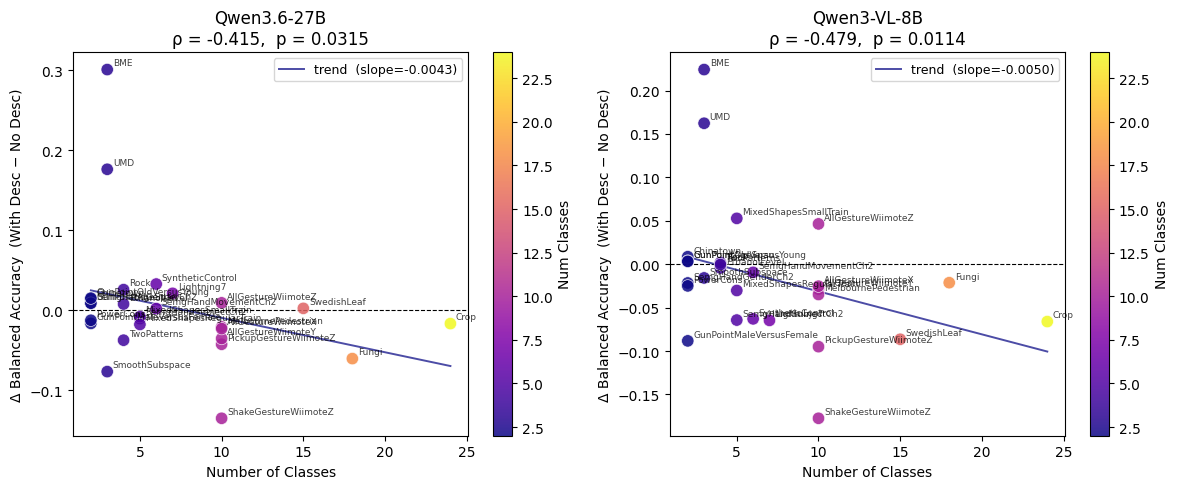

In [37]:
# ── Scatter: Num Classes vs Δ per model ──────────────────────────────────────
COLORS_BY_CLASSES = plt.cm.plasma

fig, axes = plt.subplots(1, len(available_deltas), figsize=(6 * len(available_deltas), 5),
                         sharey=False)
if len(available_deltas) == 1:
    axes = [axes]

for ax, (col, model_label) in zip(axes, available_deltas):
    paired = tbl_show[["Num Classes", col]].dropna()
    x = paired["Num Classes"].values
    y = paired[col].values

    sc = ax.scatter(x, y, c=x, cmap="plasma", s=80, alpha=0.85,
                    edgecolors="white", linewidths=0.5, zorder=3)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

    # trend line
    if len(x) > 2:
        z = np.polyfit(x, y, 1)
        xfit = np.linspace(x.min(), x.max(), 100)
        ax.plot(xfit, np.polyval(z, xfit), color="navy", linewidth=1.4,
                linestyle="-", alpha=0.7, label=f"trend  (slope={z[0]:+.4f})")

    rho, p_val = spearmanr(x, y)
    ax.set_xlabel("Number of Classes")
    ax.set_ylabel("Δ Balanced Accuracy  (With Desc − No Desc)")
    ax.set_title(f"{model_label}\nρ = {rho:+.3f},  p = {p_val:.4f}")
    ax.legend(fontsize=9)

    for i, task in enumerate(paired.index):
        ax.annotate(task, (x[i], y[i]), fontsize=6.5, alpha=0.75,
                    xytext=(4, 3), textcoords="offset points")

    plt.colorbar(sc, ax=ax, label="Num Classes")

plt.tight_layout()
plt.show()

## 4 · Statistical Test — Wilcoxon Signed-Rank

Paired test per model: is **With Description** significantly better than **No Description**?

In [38]:
tbl = mean_p.drop(index="Macro Avg", errors="ignore")

def sig(p):
    return '*** (p<0.001)' if p < 0.001 else '** (p<0.01)' if p < 0.01 else '* (p<0.05)' if p < 0.05 else 'n.s.'

model_pairs = [
    (COND_27B_NO, COND_27B_WITH, "Qwen3.6-27B"),
    (COND_8B_NO,  COND_8B_WITH,  "Qwen3-VL-8B"),
]

for cond_a, cond_b, model_label in model_pairs:
    if cond_a not in tbl.columns or cond_b not in tbl.columns:
        print(f"{model_label}: data not available\n"); continue
    paired = tbl[[cond_a, cond_b]].dropna()
    a_vals, b_vals = paired[cond_a].values, paired[cond_b].values
    stat_2, p_2 = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="two-sided")
    stat_g, p_g = wilcoxon(b_vals, a_vals, zero_method="pratt", alternative="greater")

    print(f"{'─'*50}")
    print(f"{model_label}")
    print(f"  Paired datasets    : {len(paired)}")
    print(f"  Mean No Desc       : {a_vals.mean():.4f}")
    print(f"  Mean With Desc     : {b_vals.mean():.4f}")
    print(f"  Mean Δ (with − no) : {(b_vals - a_vals).mean():+.4f}")
    print(f"  Wilcoxon two-sided : stat={stat_2:.1f},  p={p_2:.4f}  {sig(p_2)}")
    print(f"  Wilcoxon greater   : stat={stat_g:.1f},  p={p_g:.4f}  {sig(p_g)}")
    print()

──────────────────────────────────────────────────
Qwen3.6-27B
  Paired datasets    : 27
  Mean No Desc       : 0.5402
  Mean With Desc     : 0.5444
  Mean Δ (with − no) : +0.0042
  Wilcoxon two-sided : stat=151.0,  p=0.3735  n.s.
  Wilcoxon greater   : stat=151.0,  p=0.8196  n.s.

──────────────────────────────────────────────────
Qwen3-VL-8B
  Paired datasets    : 27
  Mean No Desc       : 0.4649
  Mean With Desc     : 0.4493
  Mean Δ (with − no) : -0.0155
  Wilcoxon two-sided : stat=100.0,  p=0.0319  * (p<0.05)
  Wilcoxon greater   : stat=100.0,  p=0.9850  n.s.



## 5 · Critical Difference Diagram

All 4 conditions ranked. Conditions connected by a bar are not significantly different (Holm-corrected Wilcoxon).

Datasets used: 27  (dropped 3 incomplete)
Average ranks (lower = better):
classifier_name
27B · With Desc    1.666667
27B · No Desc      1.703704
8B · No Desc       3.111111
8B · With Desc     3.518519

Pairwise Wilcoxon + Holm:
  ✓  27B · With Desc  vs  8B · With Desc  — p=0.0000
  ✓  27B · With Desc  vs  8B · No Desc  — p=0.0000
  ✓  27B · No Desc  vs  8B · No Desc  — p=0.0001
  ✓  27B · No Desc  vs  8B · With Desc  — p=0.0003
  ✗  8B · No Desc  vs  8B · With Desc  — p=0.0319
  ✗  27B · No Desc  vs  27B · With Desc  — p=0.3735


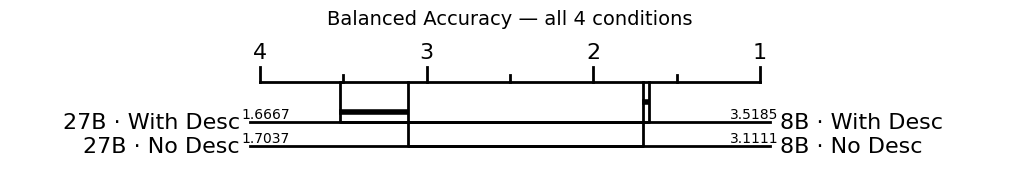

In [39]:
def graph_ranks(avranks, names, p_values, lowv=None, highv=None,
                width=7, textspace=1.5, reverse=False, labels=False):
    width, textspace = float(width), float(textspace)
    sums, nnames = avranks, names
    if lowv is None: lowv = min(1, int(math.floor(min(sums))))
    if highv is None: highv = max(len(avranks), int(math.ceil(max(sums))))
    cline = 0.4 + 0.25
    k = len(sums)
    scalewidth = width - 2 * textspace
    def rankpos(rank):
        a = highv - rank if reverse else rank - lowv
        return textspace + scalewidth / (highv - lowv) * a
    minnotsig = 2 * 0.2
    height = cline + ((k + 1) / 2) * 0.2 + minnotsig
    fig = plt.figure(figsize=(width, height))
    fig.set_facecolor("white")
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_axis_off()
    hf, wf = 1. / height, 1. / width
    ax.plot([0, 1], [0, 1], c="w"); ax.set_xlim(0, 1); ax.set_ylim(1, 0)
    def line(pts, color="k", **kw):
        ax.plot([wf * p[0] for p in pts], [hf * p[1] for p in pts], color=color, **kw)
    def text(x, y, s, **kw): ax.text(wf * x, hf * y, s, **kw)
    line([(textspace, cline), (width - textspace, cline)], linewidth=2)
    tick = None
    for a in list(np.arange(lowv, highv, 0.5)) + [highv]:
        tick = 0.15 if a != int(a) else 0.3
        line([(rankpos(a), cline - tick / 2), (rankpos(a), cline)], linewidth=2)
    for a in range(lowv, highv + 1):
        text(rankpos(a), cline - tick / 2 - 0.05, str(a), ha="center", va="bottom", size=16)
    space = 0.24
    for i in range(math.ceil(k / 2)):
        chei = cline + minnotsig + i * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei), (textspace - 0.1, chei)], linewidth=2)
        if labels: text(textspace + 0.3, chei - 0.075, f"{sums[i]:.4f}", ha="right", va="center", size=10)
        text(textspace - 0.2, chei, nnames[i], ha="right", va="center", size=16)
    for i in range(math.ceil(k / 2), k):
        chei = cline + minnotsig + (k - i - 1) * space
        line([(rankpos(sums[i]), cline), (rankpos(sums[i]), chei), (textspace + scalewidth + 0.1, chei)], linewidth=2)
        if labels: text(textspace + scalewidth - 0.3, chei - 0.075, f"{sums[i]:.4f}", ha="left", va="center", size=10)
        text(textspace + scalewidth + 0.2, chei, nnames[i], ha="left", va="center", size=16)
    m = len(nnames)
    g_data = np.zeros((m, m), dtype=np.int64)
    for p in p_values:
        if not p[3]:
            i = np.where(nnames == p[0])[0][0]
            j = np.where(nnames == p[1])[0][0]
            g_data[min(i,j), max(i,j)] = 1
    start = cline + 0.2
    for clq in networkx.find_cliques(networkx.Graph(g_data)):
        if len(clq) == 1: continue
        line([(rankpos(sums[min(clq)]) - 0.02, start),
              (rankpos(sums[max(clq)]) + 0.02, start)], linewidth=4)
        start += 0.1


def draw_cd_diagram(df_perf, alpha=0.05, title=None, labels=False):
    classifiers = df_perf["classifier_name"].unique().tolist()
    p_values = []
    for i in range(len(classifiers) - 1):
        for j in range(i + 1, len(classifiers)):
            c1, c2 = classifiers[i], classifiers[j]
            d1 = df_perf[df_perf["classifier_name"] == c1].set_index("dataset_name")["accuracy"]
            d2 = df_perf[df_perf["classifier_name"] == c2].set_index("dataset_name")["accuracy"]
            common = d1.index.intersection(d2.index)
            if len(common) < 2: continue
            p = wilcoxon(d1[common].values, d2[common].values, zero_method="pratt")[1]
            p_values.append([c1, c2, p, False])
    p_values.sort(key=lambda x: x[2])
    for i, pv in enumerate(p_values):
        pv[3] = pv[2] <= alpha / (len(p_values) - i)
    pivot = df_perf.pivot(index="dataset_name", columns="classifier_name", values="accuracy")
    # rank axis=1: rank conditions 1..k within each dataset row (not datasets within each condition)
    avg_ranks = pivot.rank(axis=1, ascending=False).mean(axis=0).sort_values(ascending=True)
    print("Average ranks (lower = better):")
    print(avg_ranks.to_string())
    print("\nPairwise Wilcoxon + Holm:")
    for p in p_values:
        print(f"  {'✓' if p[3] else '✗'}  {p[0]}  vs  {p[1]}  — p={p[2]:.4f}")
    graph_ranks(avg_ranks.values, avg_ranks.index.values,
                [tuple(p) for p in p_values],
                reverse=True, width=10, textspace=2.5, labels=labels)
    if title:
        plt.title(title, fontsize=14, y=0.9, x=0.5)
    plt.show()


tbl        = mean_p.drop(index="Macro Avg", errors="ignore")
stat_cols  = [c for c in CONDITIONS if c in tbl.columns]
pivot_stat = tbl[stat_cols].dropna()
print(f"Datasets used: {len(pivot_stat)}  (dropped {len(tbl) - len(pivot_stat)} incomplete)")

df_perf = (
    pivot_stat.reset_index()
    .melt(id_vars="Task", var_name="classifier_name", value_name="accuracy")
    .rename(columns={"Task": "dataset_name"})
)

draw_cd_diagram(df_perf=df_perf, alpha=0.05, title="Balanced Accuracy — all 4 conditions", labels=True)